# Data Analysis Challenge - Group 9 (Adam Chorzepa, Matthew Gockiewicz)


First, we loaded the provided dataset using pandas and displayed the first few rows, in order to understand the structure and contents of the dataset. This helped us recognize what was available to us, which is: post_id, user_id, post_data, post_type, likes, comments, shares, time_posted, hashtags_count, follower_count.

In [27]:
import pandas as pd

# Load the dataset
df = pd.read_csv("team09_social_media.csv")

# Show the first rows
df.head()

,post_id,user_id,post_date,post_type,likes,comments,shares,time_posted,hashtags_count,follower_count
0,1,357,2023-09-11,Video,15.0,2,21,Afternoon,1,922.0
1,2,376,2023-03-08,Photo,75.0,20,14,Night,4,382.0
2,3,175,2023-04-13,Link,283.0,13,4,Afternoon,2,480.0
3,4,159,2023-12-21,Video,215.0,8,3,Morning,4,96.0
4,5,244,2023-10-10,Photo,225.0,13,3,Evening,0,1043.0


Next, we computed df.shape to find the amount of rows and columns in the dataset. Df.columns to check column names, df.info to check data types, and df.describe to display the average likes, min, max, mean, and outliers.

In [28]:
df.shape

(1500, 10)

In [29]:
df.columns

Index(['post_id', 'user_id', 'post_date', 'post_type', 'likes', 'comments',
       'shares', 'time_posted', 'hashtags_count', 'follower_count'],
      dtype='str')

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   post_id         1500 non-null   int64  
 1   user_id         1500 non-null   int64  
 2   post_date       1500 non-null   str    
 3   post_type       1500 non-null   str    
 4   likes           1426 non-null   float64
 5   comments        1500 non-null   int64  
 6   shares          1500 non-null   int64  
 7   time_posted     1500 non-null   str    
 8   hashtags_count  1500 non-null   int64  
 9   follower_count  1450 non-null   float64
dtypes: float64(2), int64(5), str(3)
memory usage: 117.3 KB


In [31]:
df.describe()

,post_id,user_id,likes,comments,shares,hashtags_count,follower_count
count,1500.000000,1500.000000,1426.000000,1500.000000,1500.000000,1500.000000,1450.000000
mean,750.500000,200.530667,102.036466,14.729333,4.596667,2.979333,1009.070345
std,433.157015,116.349017,74.279114,12.597481,5.025816,1.668361,704.991558
min,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,50.000000
25%,375.750000,100.000000,48.000000,5.000000,1.000000,2.000000,496.250000
50%,750.500000,201.000000,85.000000,12.000000,3.000000,3.000000,850.000000
75%,1125.250000,302.250000,138.000000,21.000000,7.000000,4.000000,1372.750000
max,1500.000000,399.000000,553.000000,88.000000,33.000000,10.000000,4493.000000


In [32]:
print("\npost_type:")
print(df['post_type'].unique())

print("\ntime_posted:")
print(df['time_posted'].unique())


post_type:
<StringArray>
['Video', 'Photo', 'Link', 'Text']
Length: 4, dtype: str

time_posted:
<StringArray>
['Afternoon', 'Night', 'Morning', 'Evening']
Length: 4, dtype: str


We then which values were unique in each key categorical column of the dataset, including post_type, and time_posted.



Next, we checked for missing values in the dataset. This shows that there are 74 missing values in the 'likes' column, and 50 missing values in the 'follower_count' column. All other columns in the dataset contain 0 missing values, which means they are complete.

In [33]:
df.isnull().sum()

post_id            0
user_id            0
post_date          0
post_type          0
likes             74
comments           0
shares             0
time_posted        0
hashtags_count     0
follower_count    50
dtype: int64

Since the dataset contains missing values in the likes and follower_count columns, and social media engagement can be easily skewed with extreme high values, we decided to use median rather than mean to represent the missing values. The median is more resistant to outliers.

In [34]:
df['likes'] = df['likes'].fillna(df['likes'].median())
df['follower_count'] = df['follower_count'].fillna(df['follower_count'].median())

df.isnull().sum()

post_id           0
user_id           0
post_date         0
post_type         0
likes             0
comments          0
shares            0
time_posted       0
hashtags_count    0
follower_count    0
dtype: int64

The missing values were fixed by replacing the likes and follower_count columns with the median of each column. Now, there are no more missing values in the data set.

In [35]:
df['post_date'] = pd.to_datetime(df['post_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   post_id         1500 non-null   int64         
 1   user_id         1500 non-null   int64         
 2   post_date       1500 non-null   datetime64[us]
 3   post_type       1500 non-null   str           
 4   likes           1500 non-null   float64       
 5   comments        1500 non-null   int64         
 6   shares          1500 non-null   int64         
 7   time_posted     1500 non-null   str           
 8   hashtags_count  1500 non-null   int64         
 9   follower_count  1500 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(5), str(2)
memory usage: 117.3 KB


We then, converted the date time format so that it would allow time-based analysis such as monthly engagement trends. Pandas now understands it as a real date and can extract year, month, sort, perform calculations, etc.

In [36]:
df['engagement'] = df['likes'] + df['comments'] + df['shares']
df.head()

,post_id,user_id,post_date,post_type,likes,comments,shares,time_posted,hashtags_count,follower_count,engagement
0,1,357,2023-09-11,Video,15.0,2,21,Afternoon,1,922.0,38.0
1,2,376,2023-03-08,Photo,75.0,20,14,Night,4,382.0,109.0
2,3,175,2023-04-13,Link,283.0,13,4,Afternoon,2,480.0,300.0
3,4,159,2023-12-21,Video,215.0,8,3,Morning,4,96.0,226.0
4,5,244,2023-10-10,Photo,225.0,13,3,Evening,0,1043.0,241.0


Next, we created a new engagement column by summing the likes, columns, and shares. This represents the total engagement per post and will be used throughout the entire anlaysis.

In [37]:
(df[['likes','comments','shares','hashtags_count','follower_count']] < 0).sum()

likes             0
comments          0
shares            0
hashtags_count    0
follower_count    0
dtype: int64

We checked for invalid values in the data, and none were found.

Next, we checked for outliers in the data.

In [38]:
df[['likes','comments','shares','follower_count']].describe()

,likes,comments,shares,follower_count
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,101.196000,14.729333,4.596667,1003.768000
std,72.516449,12.597481,5.025816,693.722434
min,2.000000,0.000000,0.000000,50.000000
25%,49.750000,5.000000,1.000000,506.000000
50%,85.000000,12.000000,3.000000,850.000000
75%,133.000000,21.000000,7.000000,1345.250000
max,553.000000,88.000000,33.000000,4493.000000


Although there are some higher values, like 553 likes and 4493 followers, we decided to keep these because they are realistic for social media.

Moving on to Analysis, we first will check which post type recieves the most engagement.

In [39]:
df.groupby('post_type')['engagement'].mean().sort_values(ascending=False)

post_type
Photo    124.126246
Link     121.368421
Text     118.766773
Video    115.742021
Name: engagement, dtype: float64

This shows that photo posts recieves the most engagement with 124.1.


Next, we checked which time of day generates the highest average likes.

In [40]:
df.groupby('time_posted')['likes'].mean().sort_values(ascending=False)

time_posted
Afternoon    109.349333
Morning      100.730000
Evening       99.489362
Night         94.808023
Name: likes, dtype: float64

This shows that afternoons generate the highest average likes. To calculate this, we calculated the average number of likes for each time category.

Next, we checked if follower count correlates with engagement.

In [41]:
df[['follower_count','engagement']].corr()

,follower_count,engagement
follower_count,1.000000,0.013922
engagement,0.013922,1.000000


There is almost no correlation between follower count and engagement. We calculated this using the pearson correlation coefficient. The value of 0.0139 is very close to 0 and suggests that there is almost no linear relationship between follower count and engagement.

Next, we group by hashtags_count to find the optimal amount of hashtags for maximum engagement.

In [42]:
df.groupby('hashtags_count')['engagement'].mean().sort_values(ascending=False)

hashtags_count
9     309.000000
10    158.000000
0     128.815789
6     128.580247
5     125.643357
7     124.000000
1     120.725118
2     119.207715
4     118.197674
3     117.304225
8      95.500000
Name: engagement, dtype: float64

9 hashtags have 309 engagement, which is almost double the next highest value and is much higher than all the other categories. This could mean there are few posts with 9 hashtags, or a few viral posts inflated the average. Therefore, in the next cell, we check how many posts have 9 hashtags.

In [43]:
df['hashtags_count'].value_counts()

hashtags_count
3     355
2     337
4     258
1     211
5     143
6      81
0      76
7      29
8       8
10      1
9       1
Name: count, dtype: int64

Since there's only 1 post with 9 hashtags, this should not be considered the optial number of hashtags since it is an outlier and is skewing the average. Therefore, instead of relying on the sorted result, we will look at average engagement and the number of posts in each hashtag category

In [44]:
df.groupby('hashtags_count').agg({
    'engagement': 'mean',
    'post_id': 'count'
}).sort_values(by='engagement', ascending=False)

,engagement,post_id
hashtags_count,,
9,309.000000,1
10,158.000000,1
0,128.815789,76
6,128.580247,81
5,125.643357,143
7,124.000000,29
1,120.725118,211
2,119.207715,337
4,118.197674,258


This data shows that engagement does not increase consistently with more hastags. Posts with 5-6 hashtags perform well, but posts wiht 0 hashtags perform similaryly.

Next, we calculate the average shares by Post Type.

In [45]:
df.groupby('post_type')['shares'].mean().sort_values(ascending=False)

post_type
Video    4.702128
Text     4.610224
Photo    4.588040
Link     4.411483
Name: shares, dtype: float64

This suggests that video posts have the highest average share rate, however, the differences are really small, which suggests that post format does not dramatically impact share behaviour in this dataset.

Next, we analyze how engagement varies every month by extracting the month, and then calculating monthly engagement.

In [46]:
df['month'] = df['post_date'].dt.month
df.groupby('month')['engagement'].mean().sort_values(ascending=False)

month
7     142.097345
4     127.717949
5     125.296000
12    124.168067
1     123.252033
11    122.214286
10    120.417910
8     118.173228
6     118.076271
3     116.226950
9     107.693431
2     104.725000
Name: engagement, dtype: float64

This shows that July has the highest engagement with 142.10, and February has the lowest with 104.73. From the data, it appears that the mid-year contains higher engagement, lower engagement early in the year, and moderate engagement toward the end of the year.

## Step 5: Visualization

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#### V1: Engagement by post type

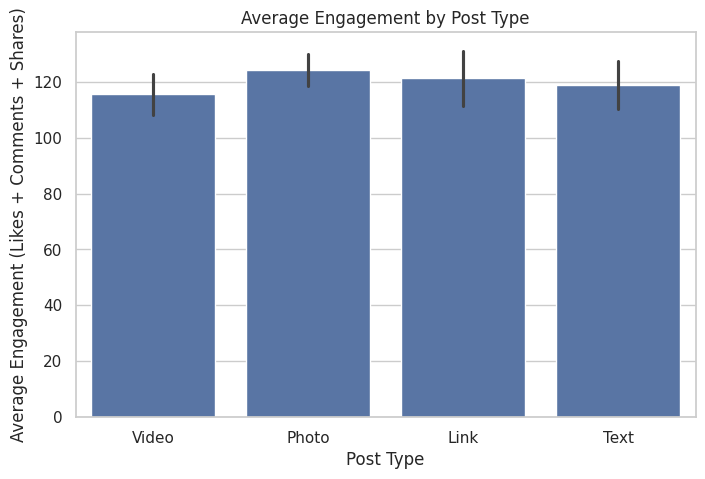

In [48]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='post_type',
    y='engagement',
    estimator='mean'
)

plt.title("Average Engagement by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Average Engagement (Likes + Comments + Shares)")

plt.show()

This graph shows the average engagement (likes + comments + shares) for each type of post. Photo posts generate the highest average engagement compared to videos, text posts, and links.

#### V2: Average Likes by time of day

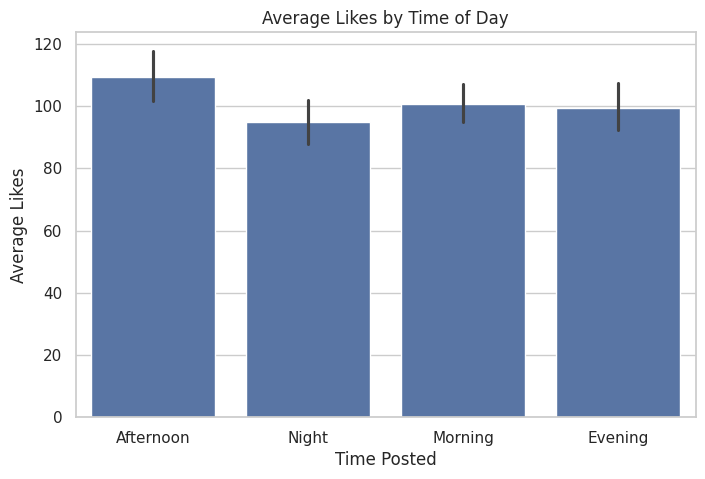

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='time_posted',
    y='likes',
    estimator='mean'
)

plt.title("Average Likes by Time of Day")
plt.xlabel("Time Posted")
plt.ylabel("Average Likes")

plt.show()

This graph compares the average number of likes received by posts depending on the time of day they were posted. The results show that posts made in the afternoon receive the highest average likes. This indicates that user activity and interaction may be higher during the afternoon compared to other times of the day.

#### V3: Follower count vs Engagement

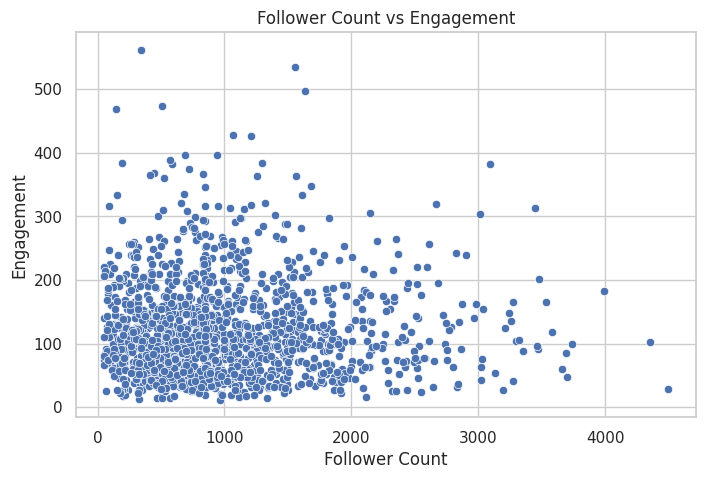

In [50]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='follower_count',
    y='engagement'
)

plt.title("Follower Count vs Engagement")
plt.xlabel("Follower Count")
plt.ylabel("Engagement")

plt.show()

This scatter plot shows the relationship between the number of followers a user has and the engagement their posts receive. The points are widely spread with no clear upward trend, indicating a very weak relationship between follower count and engagement. This suggests that having more followers does not necessarily guarantee higher engagement.

#### V4: Engagement by Month

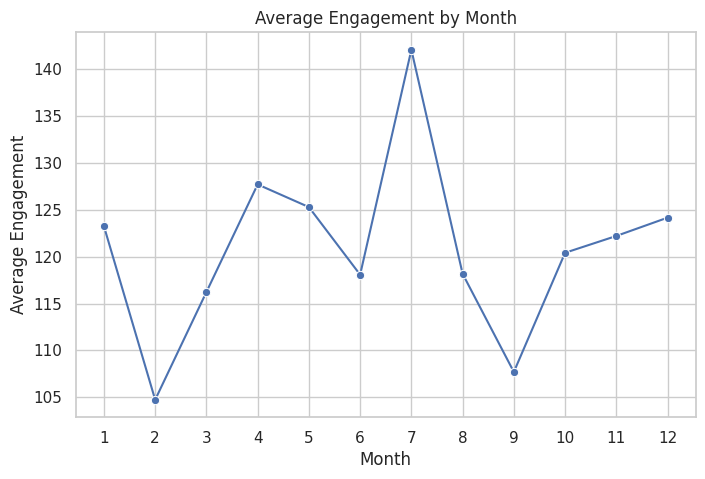

In [51]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df.groupby('month')['engagement'].mean().reset_index(),
    x='month',
    y='engagement',
    marker='o'
)

plt.title("Average Engagement by Month")
plt.xlabel("Month")
plt.ylabel("Average Engagement")

plt.xticks(range(1,13))

plt.show()

This graph shows how the average engagement changes throughout the months of the year. Engagement levels fluctuate slightly from month to month, with some months showing higher interaction than others. This may indicate seasonal trends or periods when users are more active on social media.